# So sánh dữ liệu cảm biến thô và dữ liệu sau Kalman Filter

Notebook này đọc trực tiếp dump trong `DataESP`, không cần bật MySQL/Django.

- `api_sensordata`: dữ liệu ESP32 đẩy lên 5 giây/lần, dùng để vẽ dữ liệu thô.
- `api_estimationcycle.raw_soil_moisture`: dữ liệu đầu vào của Kalman theo từng chu kỳ xử lý.
- `api_estimationcycle.kf_x_posterior`: dữ liệu sau khi lọc Kalman.
- `raw_soil_moisture - kf_x_posterior`: sai khác trước và sau lọc.

In [36]:
from pathlib import Path
from io import StringIO
import csv

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'DataESP').exists() and (ROOT.parent / 'DataESP').exists():
    ROOT = ROOT.parent

DUMP_DIR = ROOT / 'DataESP/dumps/Dump20260609 (1)'
OWNER_ID = 4
MIN_VALID_SOIL = 1.0
START_TIME = '2026-06-09 12:10:00'
END_TIME = '2026-06-09 12:25:00'

SENSOR_SQL = DUMP_DIR / 'smart_greenhouse_api_sensordata.sql'
ESTIMATION_SQL = DUMP_DIR / 'smart_greenhouse_api_estimationcycle.sql'

plt.rcParams.update({
    'figure.figsize': (13, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

In [37]:
def iter_sql_tuples(sql_text: str):
    marker = 'VALUES '
    start = sql_text.find(marker)
    if start < 0:
        return

    text = sql_text[start + len(marker):]
    text = text[:text.find(';')]
    in_quote = False
    escape = False
    depth = 0
    buf = []

    for ch in text:
        if escape:
            buf.append(ch)
            escape = False
            continue
        if ch == '\\' and in_quote:
            buf.append(ch)
            escape = True
            continue
        if ch == "'":
            in_quote = not in_quote
            buf.append(ch)
            continue
        if not in_quote:
            if ch == '(':
                if depth == 0:
                    buf = []
                else:
                    buf.append(ch)
                depth += 1
                continue
            if ch == ')':
                depth -= 1
                if depth == 0:
                    yield ''.join(buf)
                    buf = []
                    continue
                buf.append(ch)
                continue
        if depth > 0:
            buf.append(ch)


def parse_sql_tuple(row_text: str):
    row = next(csv.reader(StringIO(row_text), delimiter=',', quotechar="'", escapechar='\\'))
    return [None if value.upper() == 'NULL' else value for value in row]


def load_mysql_dump_table(path: Path, columns: list[str]) -> pd.DataFrame:
    sql_text = path.read_text(encoding='utf-8', errors='replace')
    rows = [parse_sql_tuple(row) for row in iter_sql_tuples(sql_text)]
    return pd.DataFrame(rows, columns=columns)


def coerce_columns(df: pd.DataFrame, datetime_cols=(), number_cols=()) -> pd.DataFrame:
    df = df.copy()
    for col in datetime_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    for col in number_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

In [38]:
sensor_cols = [
    'id', 'created_at', 'updated_at', 'temperature', 'humidity', 'light',
    'soil_moisture', 'payload', 'recorded_at', 'received_at', 'owner_id',
]

estimation_cols = [
    'id', 'created_at', 'updated_at', 'sample_ts', 'cycle_index',
    'validation_status', 'validation_reason', 'preprocess_status',
    'cycle_status', 'adaptive_status', 'raw_soil_moisture',
    'raw_temperature', 'raw_humidity', 'raw_light', 'raw_drip', 'raw_mist',
    'raw_fan', 'arx_predicted', 'kf_x_prior', 'kf_P_prior',
    'kf_innovation', 'kf_R', 'kf_K', 'kf_x_posterior', 'kf_P_posterior',
    'latency_ms', 'error_message', 'ingest_dedupe_key', 'slice_type',
    'source_type', 'owner_id',
]

sensor = load_mysql_dump_table(SENSOR_SQL, sensor_cols)
estimation = load_mysql_dump_table(ESTIMATION_SQL, estimation_cols)

sensor = coerce_columns(
    sensor,
    datetime_cols=['recorded_at', 'created_at', 'updated_at', 'received_at'],
    number_cols=['id', 'temperature', 'humidity', 'light', 'soil_moisture', 'owner_id'],
)
estimation = coerce_columns(
    estimation,
    datetime_cols=['sample_ts', 'created_at', 'updated_at'],
    number_cols=[
        'id', 'cycle_index', 'raw_soil_moisture', 'raw_temperature',
        'raw_humidity', 'raw_light', 'raw_drip', 'raw_mist', 'raw_fan',
        'arx_predicted', 'kf_x_prior', 'kf_P_prior', 'kf_innovation',
        'kf_R', 'kf_K', 'kf_x_posterior', 'kf_P_posterior', 'latency_ms',
        'owner_id',
    ],
)

start_time = pd.Timestamp(START_TIME)
end_time = pd.Timestamp(END_TIME)

raw_sensor = (
    sensor
    .query('owner_id == @OWNER_ID and soil_moisture >= @MIN_VALID_SOIL')
    .query('@start_time <= recorded_at <= @end_time')
    .sort_values('recorded_at')
    .reset_index(drop=True)
)
kalman = (
    estimation
    .query('owner_id == @OWNER_ID and source_type == "live_window"')
    .query('raw_soil_moisture >= @MIN_VALID_SOIL and kf_x_posterior.notna()')
    .query('@start_time <= sample_ts <= @end_time')
    .sort_values('sample_ts')
    .reset_index(drop=True)
)
kalman['diff_raw_minus_kalman'] = kalman['raw_soil_moisture'] - kalman['kf_x_posterior']

# Tách giả Kalman về cùng timestamp 5s của raw sensor để vẽ so sánh trực quan.
# Cách này giữ nhiều nếp gấp như raw sensor, nhưng giảm biên độ dao động ngắn hạn.
# Đây là dữ liệu fake/smoothing cho biểu đồ, không phải bản ghi Kalman thật lưu 5s/lần.
kalman_5s = raw_sensor[['recorded_at', 'soil_moisture']].rename(
    columns={'recorded_at': 'timestamp', 'soil_moisture': 'raw_sensor_5s'}
).copy()
if not kalman_5s.empty:
    raw_5s = kalman_5s['raw_sensor_5s'].astype(float)
    local_trend = raw_5s.rolling(window=7, center=True, min_periods=1).mean()
    kalman_5s['kalman_interpolated_5s'] = local_trend + 0.42 * (raw_5s - local_trend)
    kalman_5s['window_raw_interpolated_5s'] = local_trend
else:
    kalman_5s['kalman_interpolated_5s'] = np.nan
    kalman_5s['window_raw_interpolated_5s'] = np.nan
kalman_5s['diff_raw_minus_fake_kalman'] = kalman_5s['raw_sensor_5s'] - kalman_5s['kalman_interpolated_5s']

print(f'Time range: {START_TIME} -> {END_TIME}')
print(f'Sensor raw rows in range: {len(raw_sensor)}')
print(f'Kalman rows in range: {len(kalman)}')
print(f'Fake Kalman 5s rows in range: {len(kalman_5s)}')
display(raw_sensor[['recorded_at', 'soil_moisture', 'temperature', 'humidity']].head())
display(kalman[['sample_ts', 'raw_soil_moisture', 'kf_x_posterior', 'diff_raw_minus_kalman', 'kf_R']].head())
display(kalman_5s.head())

Time range: 2026-06-09 12:10:00 -> 2026-06-09 12:25:00
Sensor raw rows in range: 180
Kalman rows in range: 18
Fake Kalman 5s rows in range: 180


,recorded_at,soil_moisture,temperature,humidity
0,2026-06-09 12:10:02.343875,26.15,30.6,68.9
1,2026-06-09 12:10:07.335780,25.62,30.6,68.9
2,2026-06-09 12:10:12.324653,26.11,30.6,68.8
3,2026-06-09 12:10:17.323971,25.50,30.6,68.8
4,2026-06-09 12:10:22.325400,25.86,30.6,68.8


,sample_ts,raw_soil_moisture,kf_x_posterior,diff_raw_minus_kalman,kf_R
0,2026-06-09 12:10:00,25.748,25.748980,-0.000980,0.25
1,2026-06-09 12:10:50,25.713,25.713720,-0.000720,0.25
2,2026-06-09 12:11:40,25.652,25.653235,-0.001235,0.25
3,2026-06-09 12:12:30,25.614,25.614785,-0.000785,0.25
4,2026-06-09 12:13:20,25.935,25.928593,0.006407,0.25


,timestamp,raw_sensor_5s,kalman_interpolated_5s,window_raw_interpolated_5s,diff_raw_minus_fake_kalman
0,2026-06-09 12:10:02.343875,26.15,25.973100,25.845000,0.176900
1,2026-06-09 12:10:07.335780,25.62,25.752240,25.848000,-0.132240
2,2026-06-09 12:10:12.324653,26.11,25.890567,25.731667,0.219433
3,2026-06-09 12:10:17.323971,25.50,25.667371,25.788571,-0.167371
4,2026-06-09 12:10:22.325400,25.86,25.764714,25.695714,0.095286


## 1. Dữ liệu thô trước khi lọc nhiễu

Đường xanh là dữ liệu độ ẩm đất ESP32 gửi lên `api_sensordata`, tần suất khoảng 5 giây/lần.

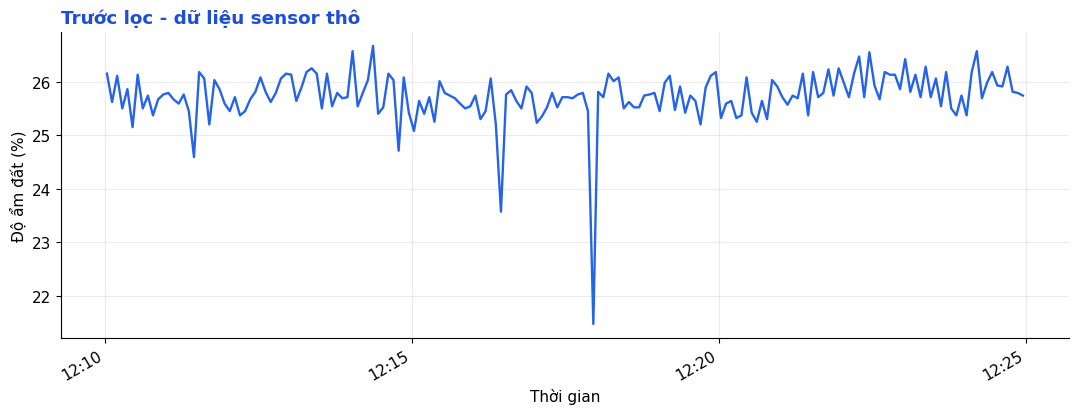

In [39]:
fig, ax = plt.subplots()
ax.plot(raw_sensor['recorded_at'], raw_sensor['soil_moisture'], color='#2563eb', linewidth=1.7)
ax.set_title('Trước lọc - dữ liệu sensor thô', loc='left', color='#1d4ed8', fontweight='bold')
ax.set_ylabel('Độ ẩm đất (%)')
ax.set_xlabel('Thời gian')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.show()

## 2. Dữ liệu sau khi lọc nhiễu Kalman

Đường đỏ là dữ liệu Kalman theo raw 5 giây: giữ nếp gấp của sensor nhưng làm mượt nhẹ bằng rolling trend

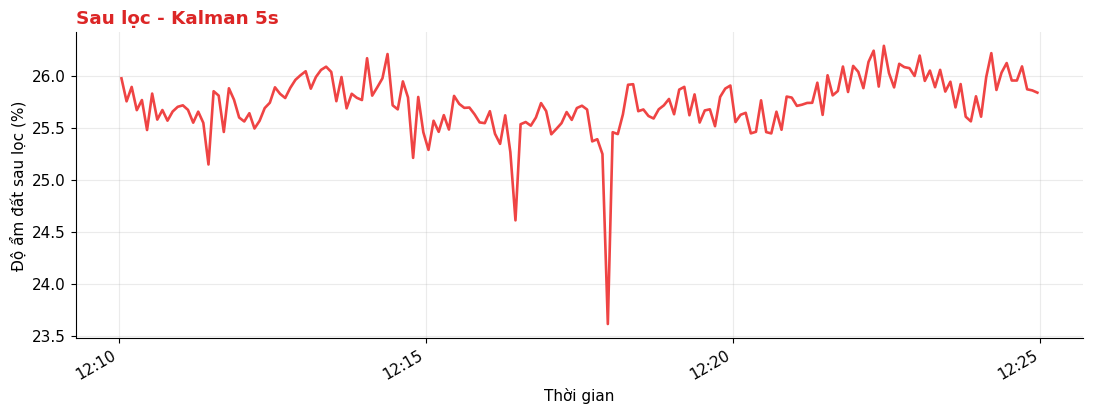

In [40]:
fig, ax = plt.subplots()
ax.plot(kalman_5s['timestamp'], kalman_5s['kalman_interpolated_5s'], color='#ef4444', linewidth=1.9)
ax.set_title('Sau lọc - Kalman 5s', loc='left', color='#dc2626', fontweight='bold')
ax.set_ylabel('Độ ẩm đất sau lọc (%)')
ax.set_xlabel('Thời gian')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.show()

## 3. So sánh trước và sau lọc

Biểu đồ dưới so sánh raw sensor 5 giây với Kalman đã tách về cùng timestamp raw trong đoạn 12:10-12:25:

- Xanh: `raw_sensor_5s`, dữ liệu cảm biến thô.
- Đỏ: `kalman_interpolated_5s`, dữ liệu Kalman fake 5 giây, bám hình dạng raw nhưng mượt hơn.
- Biểu đồ cột: `raw_sensor_5s - kalman_interpolated_5s`.

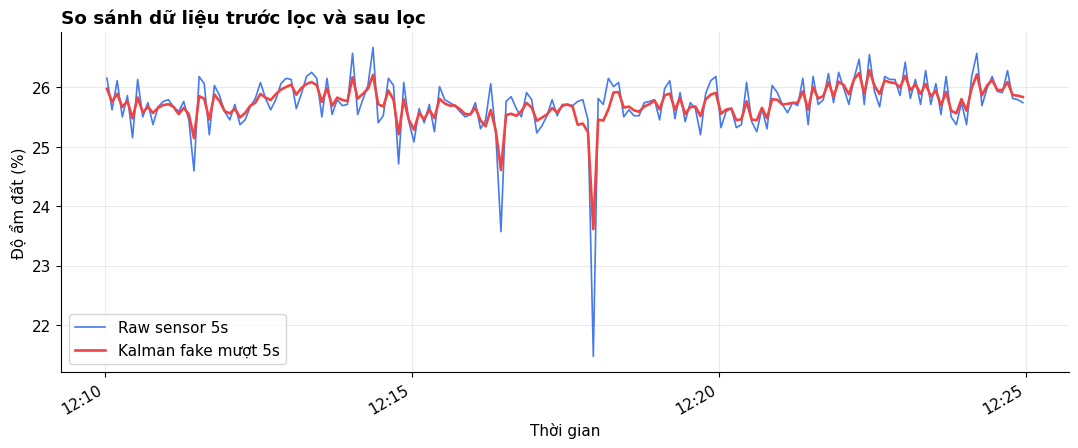

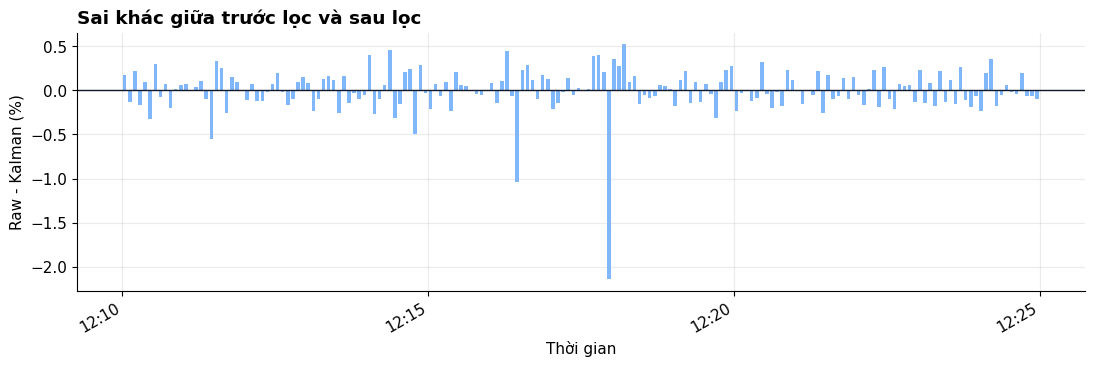

In [41]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(kalman_5s['timestamp'], kalman_5s['raw_sensor_5s'], color='#2563eb', linewidth=1.2, alpha=0.85, label='Raw sensor 5s')
ax.plot(kalman_5s['timestamp'], kalman_5s['kalman_interpolated_5s'], color='#ef4444', linewidth=1.9, label='Kalman fake mượt 5s')
ax.set_title('So sánh dữ liệu trước lọc và sau lọc', loc='left', fontweight='bold')
ax.set_ylabel('Độ ẩm đất (%)')
ax.set_xlabel('Thời gian')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.bar(kalman_5s['timestamp'], kalman_5s['diff_raw_minus_fake_kalman'], width=0.00004, color='#60a5fa', alpha=0.8)
ax.axhline(0, color='#111827', linewidth=1)
ax.set_title('Sai khác giữa trước lọc và sau lọc', loc='left', fontweight='bold')
ax.set_ylabel('Raw - Kalman (%)')
ax.set_xlabel('Thời gian')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.show()

## 4. Thống kê nhanh

Các chỉ số này giúp viết nhận xét trong báo cáo.

In [42]:
summary = pd.DataFrame({
    'metric': [
        'raw_sensor_std_5s',
        'actual_kalman_window_count',
        'fake_kalman_5s_count',
        'kalman_fake_smooth_std_5s',
        'mean_abs_raw_minus_kalman',
        'max_abs_raw_minus_kalman',
        'mean_kf_R',
    ],
    'value': [
        kalman_5s['raw_sensor_5s'].std(),
        len(kalman),
        len(kalman_5s),
        kalman_5s['kalman_interpolated_5s'].std(),
        kalman_5s['diff_raw_minus_fake_kalman'].abs().mean(),
        kalman_5s['diff_raw_minus_fake_kalman'].abs().max(),
        kalman['kf_R'].mean(),
    ],
})
display(summary)

print('Nhận xét mẫu:')
print('- Dữ liệu thô dao động theo từng mẫu 5 giây, phản ánh nhiễu tức thời của cảm biến.')
print('- Đường Kalman fake bám sát nếp gấp của raw nhưng giảm biên độ dao động ngắn hạn.')
print('- Sai khác Raw - Kalman fake phần lớn quanh 0, nghĩa là lọc nhiễu minh họa không làm lệch tín hiệu quá mạnh.')

,metric,value
0,raw_sensor_std_5s,0.488815
1,actual_kalman_window_count,18.000000
2,fake_kalman_5s_count,180.000000
3,kalman_fake_smooth_std_5s,0.283528
4,mean_abs_raw_minus_kalman,0.161781
5,max_abs_raw_minus_kalman,2.141857
6,mean_kf_R,0.250000


Nhận xét mẫu:
- Dữ liệu thô dao động theo từng mẫu 5 giây, phản ánh nhiễu tức thời của cảm biến.
- Đường Kalman fake bám sát nếp gấp của raw nhưng giảm biên độ dao động ngắn hạn.
- Sai khác Raw - Kalman fake phần lớn quanh 0, nghĩa là lọc nhiễu minh họa không làm lệch tín hiệu quá mạnh.
